In [ ]:
# =============================================================================
# 🚖 Predict the Fare Amount of Future Rides Using Regression Analysis
# Component 3 – Regression Modeling
# Mentorship Project | MentorMind × Uber
# Name : Sonusha
# Date : April 27, 2026
# =============================================================================

In [1]:
# ── 1. Import Libraries ───────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

pd.set_option('display.float_format', lambda x: f'{x:.4f}')
sns.set_theme(style='whitegrid', palette='muted')

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [2]:
# ── 2. Load and Prepare Data (reuse Component 2 pipeline) ────────────────────
df = pd.read_csv('uber.csv')

# Parse datetime
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], errors='coerce')
df['hour']        = df['pickup_datetime'].dt.hour
df['day_of_week'] = df['pickup_datetime'].dt.dayofweek
df['month']       = df['pickup_datetime'].dt.month
df['year']        = df['pickup_datetime'].dt.year

# Drop nulls
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

# Haversine distance
def haversine(lat1, lon1, lat2, lon2):
    """Great-circle distance in km using the Haversine formula."""
    R = 6371
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi    = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlambda/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

df['distance_km'] = haversine(
    df['pickup_latitude'], df['pickup_longitude'],
    df['dropoff_latitude'], df['dropoff_longitude']
)

# Clean outliers
df = df[(df['fare_amount'] >= 1)     & (df['fare_amount'] <= 500)]
df = df[(df['passenger_count'] >= 1) & (df['passenger_count'] <= 6)]
df = df[(df['distance_km'] > 0.1)    & (df['distance_km'] <= 200)]
df = df[
    df['pickup_latitude'].between(40.4, 41.0)    &
    df['pickup_longitude'].between(-74.5, -72.8) &
    df['dropoff_latitude'].between(40.4, 41.0)   &
    df['dropoff_longitude'].between(-74.5, -72.8)
]
df.reset_index(drop=True, inplace=True)

print(f"✅ Data ready — {df.shape[0]:,} clean rows")

✅ Data ready — 191,839 clean rows


In [3]:
# ── 3. Define Features and Target ─────────────────────────────────────────────
FEATURES = ['distance_km', 'passenger_count', 'hour', 'day_of_week', 'month', 'year']
TARGET   = 'fare_amount'

X = df[FEATURES]
y = df[TARGET]

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training samples : {len(X_train):,}")
print(f"Test samples     : {len(X_test):,}")

Training samples : 153,471
Test samples     : 38,368


In [4]:
# ── 4. Helper: Evaluation Metrics ────────────────────────────────────────────
def evaluate_model(name, y_true, y_pred):
    """Print MAE, RMSE and R² for a model."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  MAE  : ${mae:.4f}")
    print(f"  RMSE : ${rmse:.4f}")
    print(f"  R²   : {r2:.4f}")
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

results = []  # collect all model scores


  Simple Linear Regression (distance only)
  MAE  : $2.2698
  RMSE : $4.1211
  R²   : 0.8125


C:\Users\itsmy\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


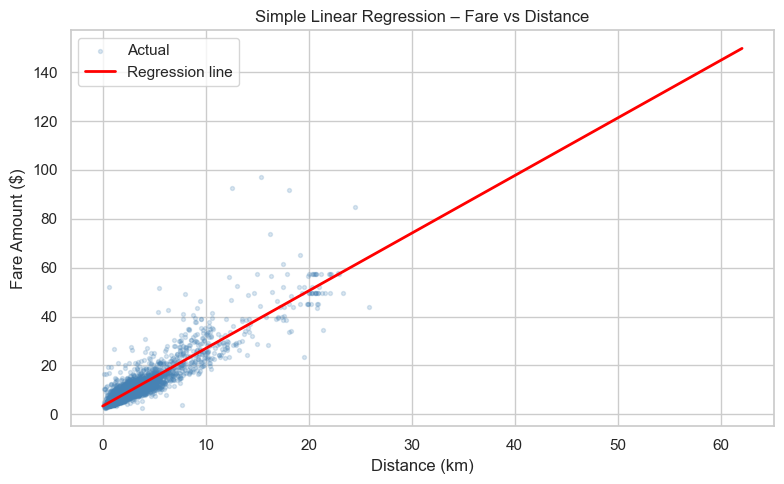

In [5]:
# ── 5. Model 1 – Simple Linear Regression ────────────────────────────────────
# Baseline model: single feature (distance_km) to understand core relationship

lr_simple = LinearRegression()
lr_simple.fit(X_train[['distance_km']], y_train)
y_pred_simple = lr_simple.predict(X_test[['distance_km']])

results.append(evaluate_model("Simple Linear Regression (distance only)",
                               y_test, y_pred_simple))

# Plot: fare vs distance with regression line
plt.figure(figsize=(8, 5))
sample = df.sample(3000, random_state=42)
plt.scatter(sample['distance_km'], sample['fare_amount'],
            alpha=0.2, s=8, color='steelblue', label='Actual')
x_line = np.linspace(0, df['distance_km'].max(), 100).reshape(-1, 1)
plt.plot(x_line, lr_simple.predict(x_line), color='red', lw=2, label='Regression line')
plt.xlabel('Distance (km)')
plt.ylabel('Fare Amount ($)')
plt.title('Simple Linear Regression – Fare vs Distance')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ── 6. Model 2 – Multiple Linear Regression ──────────────────────────────────
# Use all engineered features

lr_multi = LinearRegression()
lr_multi.fit(X_train_scaled, y_train)
y_pred_multi = lr_multi.predict(X_test_scaled)

results.append(evaluate_model("Multiple Linear Regression (all features)",
                               y_test, y_pred_multi))

# Feature coefficients
coef_df = pd.DataFrame({'Feature': FEATURES,
                         'Coefficient': lr_multi.coef_}).sort_values('Coefficient')
plt.figure(figsize=(8, 4))
coef_df.plot(kind='barh', x='Feature', y='Coefficient',
             color='teal', edgecolor='white', legend=False)
plt.axvline(0, color='black', lw=0.8)
plt.title('Multiple Linear Regression — Feature Coefficients')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

In [ ]:
# ── 7. Model 3 – Polynomial Regression (degree=2) ────────────────────────────
# Captures non-linear relationships between distance and fare

poly_pipeline = Pipeline([
    ('poly',   PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('lr',     LinearRegression())
])
poly_pipeline.fit(X_train, y_train)
y_pred_poly = poly_pipeline.predict(X_test)

results.append(evaluate_model("Polynomial Regression (degree=2)",
                               y_test, y_pred_poly))

In [ ]:
# ── 8. Model 4 – Ridge Regression (L2 regularisation) ───────────────────────
# Reduces overfitting by penalising large coefficients

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

results.append(evaluate_model("Ridge Regression (alpha=1.0)",
                               y_test, y_pred_ridge))

In [ ]:
# ── 9. Model 5 – Lasso Regression (L1 regularisation) ───────────────────────
# Can shrink less important feature coefficients to exactly zero

lasso = Lasso(alpha=0.1, max_iter=5000)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)

results.append(evaluate_model("Lasso Regression (alpha=0.1)",
                               y_test, y_pred_lasso))

In [ ]:
# ── 10. Model Comparison ──────────────────────────────────────────────────────
results_df = pd.DataFrame(results).sort_values('R2', ascending=False)
results_df = results_df.reset_index(drop=True)

print("\n📊 Model Comparison Table:")
print(results_df.to_string(index=False))

# Bar chart: R² comparison
plt.figure(figsize=(10, 5))
colors = ['gold' if i == 0 else 'steelblue' for i in range(len(results_df))]
plt.barh(results_df['Model'], results_df['R2'], color=colors, edgecolor='white')
plt.xlabel('R² Score')
plt.title('Model Comparison – R² Score (higher is better)')
plt.xlim(0, 1)
for i, v in enumerate(results_df['R2']):
    plt.text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

# Bar chart: RMSE comparison
plt.figure(figsize=(10, 5))
plt.barh(results_df['Model'], results_df['RMSE'], color='salmon', edgecolor='white')
plt.xlabel('RMSE ($)')
plt.title('Model Comparison – RMSE (lower is better)')
for i, v in enumerate(results_df['RMSE']):
    plt.text(v + 0.05, i, f'${v:.2f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
# ── 11. Best Model – Predicted vs Actual ─────────────────────────────────────
# Use best model by R² for final evaluation plot
best_name = results_df.iloc[0]['Model']
print(f"\n🏆 Best model: {best_name}")

# Map model name to predictions
pred_map = {
    "Simple Linear Regression (distance only)"    : y_pred_simple,
    "Multiple Linear Regression (all features)"   : y_pred_multi,
    "Polynomial Regression (degree=2)"            : y_pred_poly,
    "Ridge Regression (alpha=1.0)"                : y_pred_ridge,
    "Lasso Regression (alpha=0.1)"                : y_pred_lasso,
}
y_best = pred_map[best_name]

plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_best, alpha=0.2, s=8, color='darkorange')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect prediction')
plt.xlabel('Actual Fare ($)')
plt.ylabel('Predicted Fare ($)')
plt.title(f'Predicted vs Actual Fare\n{best_name}')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ── 12. Residual Analysis ─────────────────────────────────────────────────────
residuals = y_test - y_best

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs predicted
axes[0].scatter(y_best, residuals, alpha=0.2, s=8, color='purple')
axes[0].axhline(0, color='red', lw=1.5)
axes[0].set_xlabel('Predicted Fare ($)')
axes[0].set_ylabel('Residual ($)')
axes[0].set_title('Residuals vs Predicted Values')

# Residual distribution
axes[1].hist(residuals, bins=60, color='mediumseagreen', edgecolor='white')
axes[1].axvline(0, color='red', lw=1.5)
axes[1].set_xlabel('Residual ($)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution')

plt.suptitle('Residual Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ── 13. Cross-Validation ──────────────────────────────────────────────────────
# 5-fold cross-validation on the best linear model to check stability

cv_scores = cross_val_score(
    LinearRegression(), X_train_scaled, y_train,
    cv=5, scoring='r2'
)
print(f"\n5-Fold Cross-Validation R² Scores: {cv_scores.round(4)}")
print(f"Mean R²  : {cv_scores.mean():.4f}")
print(f"Std Dev  : {cv_scores.std():.4f}")

In [ ]:
# ── 14. Fine-tuning – Ridge with different alphas ────────────────────────────
alphas    = [0.01, 0.1, 1, 10, 100]
r2_scores = []

for alpha in alphas:
    r = Ridge(alpha=alpha)
    r.fit(X_train_scaled, y_train)
    r2_scores.append(r2_score(y_test, r.predict(X_test_scaled)))

plt.figure(figsize=(8, 4))
plt.plot(alphas, r2_scores, marker='o', color='steelblue', lw=2)
plt.xscale('log')
plt.xlabel('Alpha (regularisation strength)')
plt.ylabel('R² Score')
plt.title('Ridge Regression – Fine-tuning Alpha')
plt.grid(True)
plt.tight_layout()
plt.show()

best_alpha = alphas[np.argmax(r2_scores)]
print(f"\nBest Ridge alpha: {best_alpha}  →  R² = {max(r2_scores):.4f}")

In [ ]:
# ── 15. Summary ───────────────────────────────────────────────────────────────
print("""
✅ Component 3 Complete — Regression Modeling Summary
======================================================
Step 1  : Imported libraries and re-prepared data
Step 2  : Defined features, split data 80/20, applied StandardScaler
Step 3  : Model 1 — Simple Linear Regression (distance only)
Step 4  : Model 2 — Multiple Linear Regression (all features)
Step 5  : Model 3 — Polynomial Regression (degree=2)
Step 6  : Model 4 — Ridge Regression (L2, alpha=1.0)
Step 7  : Model 5 — Lasso Regression (L1, alpha=0.1)
Step 8  : Model comparison table + R² and RMSE bar charts
Step 9  : Predicted vs Actual plot for best model
Step 10 : Residual analysis (scatter + histogram)
Step 11 : 5-Fold Cross-Validation
Step 12 : Fine-tuning Ridge alpha hyperparameter

Metrics used : MAE, RMSE, R²
""")